
 Accuracy Comparison:
Decision Tree Accuracy: 0.6
Random Forest Accuracy: 0.6777777777777778

 Decision Tree Confusion matrix:
 [[29 16]
 [20 25]]

 Random forest Confusion matrix:
 [[27 18]
 [11 34]]


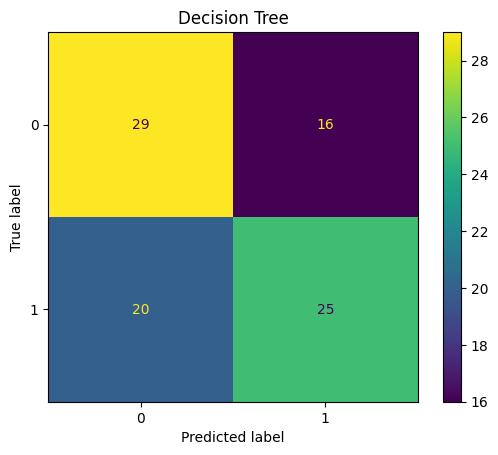

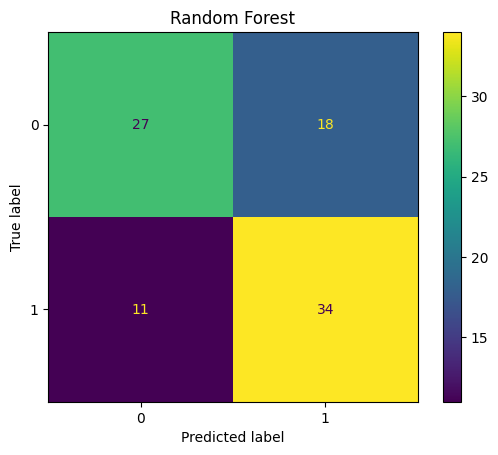


 Cross Validation Accuracy:
Decision Tree: 0.5633333333333332
Random Forest: 0.6533333333333333


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#2.Generate larger dataset
np.random.seed(42)
random.seed(42)
n_samples=300
data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertiliizer':np.random.choice(['Yes','No'],n_samples),
    'CropType':np.random.choice(['Wheat','Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
    }
df=pd.DataFrame(data)

# 3. Target with NOISE
def irrigation_rule(row):
  if row['Soil']=='Dry' and row['Weather']!='Rainy':
    base='Yes'
  elif row['Soil']=='Wet':
    base='No'
  else:
    base=random.choice(['Yes','No'])
# add noise (flip label with 20% probability)
  if random.random()<0.2:
    return 'No'if base=='Yes' else 'Yes'
  return base
df['Irrigate']=df.apply(irrigation_rule,axis=1)

#4.Encode Data
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

# 5. Split data
x=df.drop('Irrigate',axis=1)
y=df['Irrigate']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

#6. Decision tree(high variance)
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)

#7.Random forest (variance reducion)
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)

#8. Accuracy Comparision

dt_acc=accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\n Accuracy Comparison:")
print("Decision Tree Accuracy:",dt_acc)
print("Random Forest Accuracy:",rf_acc)

#9. Confusion matrix

cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\n Decision Tree Confusion matrix:\n",cm_dt)
print("\n Random forest Confusion matrix:\n",cm_rf)

#10. Visual confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title("Random Forest")
plt.show()

# 11. Cross validation
dt_cv=cross_val_score(dt_model,x,y,cv=5)
rf_cv=cross_val_score(rf_model,x,y,cv=5)

print("\n Cross Validation Accuracy:")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())



